### __Calibration__


C:\Users\super\AppData\Local\Temp\ipykernel_33480\1828487439.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(lin, x_measured, y_nominal)


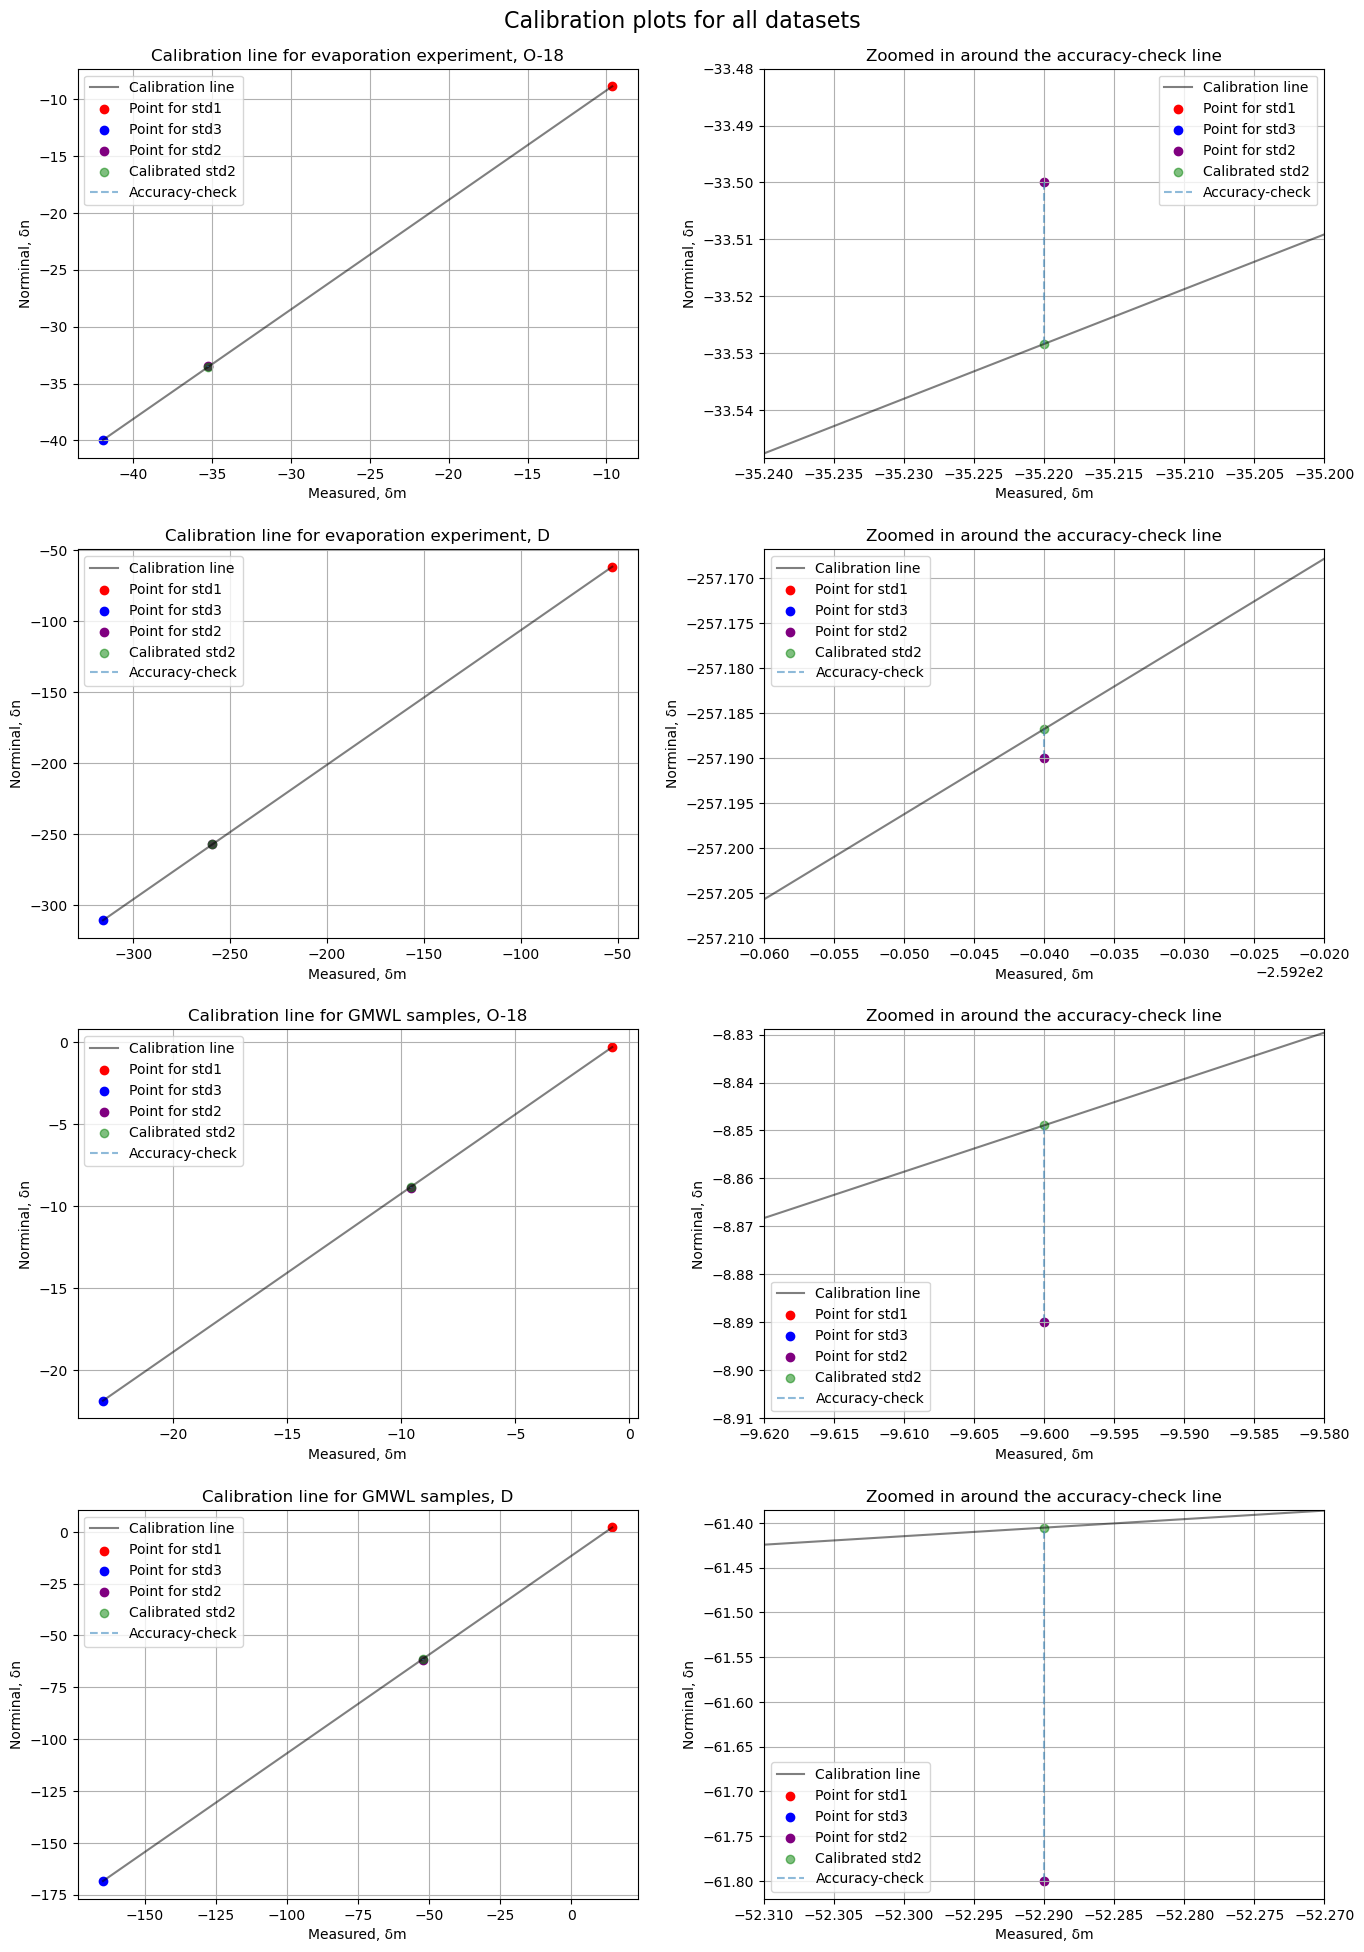

In [5]:
#Package imports:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#Linear model defines:
def lin(x, a, b):
    return a * x + b

#Values for the measured and nominal standards defines:
#First experiment
#18_O
std1_1M_18O=-9.63         #Measured
std1_1N_18O=-8.89         #Nominal

std3_1M_18O=-41.9
std3_1N_18O=-39.96

std2_1M_18O=-35.22
std2_1N_18O=-33.5

#D
std1_1M_d=-52.73        
std1_1N_d=-61.8         

std3_1M_d=-315.62
std3_1N_d=-310.53

std2_1M_d=-259.24
std2_1N_d=-257.19

#Second experiment
#18_O
std1_2M_18O=-0.75        #Measured
std1_2N_18O=-0.30         #Nominal

std3_2M_18O=-23.09
std3_2N_18O=-21.88

std2_2M_18O=-9.6
std2_2N_18O=-8.89

#D
std1_2M_d=14.43       
std1_2N_d=2.1        

std3_2M_d=-164.68
std3_2N_d=-168.38

std2_2M_d=-52.29
std2_2N_d=-61.8


std1_M = np.array([std1_1M_18O, std1_1M_d, std1_2M_18O, std1_2M_d])
std1_N = np.array([std1_1N_18O, std1_1N_d, std1_2N_18O, std1_2N_d])
std3_M = np.array([std3_1M_18O, std3_1M_d, std3_2M_18O, std3_2M_d])
std3_N = np.array([std3_1N_18O, std3_1N_d, std3_2N_18O, std3_2N_d])
std2_M = np.array([std2_1M_18O, std2_1M_d, std2_2M_18O, std2_2M_d])
std2_N = np.array([std2_1N_18O, std2_1N_d, std2_2N_18O, std2_2N_d])

measured=np.array([std1_M, std3_M])
nominal=np.array([std1_N, std3_M])

T_list = ["evaporation experiment, O-18","evaporation experiment, D","GMWL samples, O-18","GMWL samples, D",]

fig, axs = plt.subplots(4, 2, figsize=(14,20))
fig.suptitle("Calibration plots for all datasets", fontsize=16)



for i in range(4):
    x_measured=np.array([std1_M[i], std3_M[i]])
    y_nominal=np.array([std1_N[i], std3_N[i]])

    par, cov = curve_fit(lin, x_measured, y_nominal)
    a, b = par

    #Line for the plot:
    x=np.linspace(min(x_measured), max(x_measured), 100)
    y=lin(x, *par)

    #Now std2 is used:
    std2_k=lin(std2_M[i], *par)    #Calibrated std2
    std2_a=std2_k-std2_N[i]        #Deviation

    #The subplots:
    axs[i,0].plot(x, y, label="Calibration line", color="black", alpha=0.5)
    axs[i,0].scatter([std1_M[i]], [std1_N[i]], label="Point for std1", color="r")
    axs[i,0].scatter([std3_M[i]], [std3_N[i]], label="Point for std3", color="b")
    axs[i,0].scatter([std2_M[i]], [std2_N[i]], label="Point for std2", color="purple")
    axs[i,0].scatter([std2_M[i]], [std2_k], label="Calibrated std2", color="g", alpha=0.5)

    axs[i,0].plot([std2_M[i] , std2_M[i]], [std2_N[i], std2_k], linestyle="--", alpha=0.5, label="Accuracy-check")
    axs[i,0].set_title(f"Calibration line for {T_list[i]}")
    axs[i,0].set_xlabel("Measured, δm")
    axs[i,0].set_ylabel("Norminal, δn")
    axs[i,0].grid()
    axs[i,0].legend()

    #The subplots zoomed in:
    axs[i,1].plot(x, y, label="Calibration line", color="black", alpha=0.5)
    axs[i,1].scatter([std1_M[i]], [std1_N[i]], label="Point for std1", color="r")
    axs[i,1].scatter([std3_M[i]], [std3_N[i]], label="Point for std3", color="b")
    axs[i,1].scatter([std2_M[i]], [std2_N[i]], label="Point for std2", color="purple")
    axs[i,1].scatter([std2_M[i]], [std2_k], label="Calibrated std2", color="g", alpha=0.5)

    axs[i,1].plot([std2_M[i] , std2_M[i]], [std2_N[i], std2_k], linestyle="--", alpha=0.5, label="Accuracy-check")
    
    axs[i,1].set_xlim(std2_M[i]-0.02, std2_M[i]+0.02)
    axs[i,1].set_ylim(min(std2_N[i],std2_k)-0.02,max(std2_N[i],std2_k)+0.02)

    axs[i,1].set_title("Zoomed in around the accuracy-check line")
    axs[i,1].set_xlabel("Measured, δm")
    axs[i,1].set_ylabel("Norminal, δn")
    axs[i,1].grid()
    axs[i,1].legend()

plt.tight_layout(pad=2)

plt.savefig("calibration_plots.png", dpi = 500, bbox_inches = "tight")




    




### __Z-scores for linear scale vs log-log scale__

In [2]:
#Values defines
linearscale_C = 0.9467
delta_linearscale_C = 3*10**(-5)

loglogscale_C = 0.9465 
delta_loglogscale_C = 3*10**(-5)

linearscale_G = 0.9218 
delta_linearscale_G = 4*10**(-5)

loglogscale_G = 0.9210 
delta_loglogscale_G = 3*10**(-5)

#Deviation:
D_C = linearscale_C-loglogscale_C
D_G = linearscale_G-loglogscale_G


#Errors:
delta_D_C = np.sqrt(delta_linearscale_C**2 + delta_loglogscale_C**2)
delta_D_G = np.sqrt(delta_linearscale_G**2 + delta_loglogscale_G**2)


# Z-score:
z_C = D_C/delta_D_C
z_G = D_G/delta_D_G 


print(f"Linear scale, fractionation factor for Copenhagen = {linearscale_C} ± {delta_linearscale_C:.5f}")
print(f"Log-log scale, fractionation factor for Copenhagen = {loglogscale_C} ± {delta_loglogscale_C :.5f}")
print(f"The deviation for Copenhagen = {D_C:.5f}")
print(f"The z-score for Copenhagen = {z_C:.5f}")
print("\n")
print(f"Linear scale, fractionation factor for Greenland = {linearscale_G} ± {delta_linearscale_G:.5f}")
print(f"Log-log scale, fractionation factor for Greenland= {loglogscale_G} ± {delta_loglogscale_G:.5f}")
print(f"The deviation for Greenland = {D_G:.5f}")
print(f"The z-score for Greenland = {z_G:.5f}")



Linear scale, fractionation factor for Copenhagen = 0.9467 ± 0.00003
Log-log scale, fractionation factor for Copenhagen = 0.9465 ± 0.00003
The deviation for Copenhagen = 0.00020
The z-score for Copenhagen = 4.71405


Linear scale, fractionation factor for Greenland = 0.9218 ± 0.00004
Log-log scale, fractionation factor for Greenland= 0.921 ± 0.00003
The deviation for Greenland = 0.00080
The z-score for Greenland = 16.00000


### __Z-scores for Copenhagen vs Greenland__

In [3]:
#Deviation between Copenhagen and Greenland:
D_linearscale = linearscale_C-linearscale_G
D_loglogscale = loglogscale_C-loglogscale_G


#Errors:
delta_D_linearscale = np.sqrt(delta_linearscale_C**2 + delta_linearscale_G**2)
delta_D_loglogscale= np.sqrt(delta_loglogscale_C**2 + delta_loglogscale_G**2)


# Z-score:
z_linearscale = D_linearscale/delta_D_linearscale
z_loglogscale= D_loglogscale/delta_D_loglogscale 


print(f"Linear scale, fractionation factor for Copenhagen = {linearscale_C} ± {delta_linearscale_C:4f}")
print(f"Log-log scale, fractionation factor for Copenhagen = {loglogscale_C} ± {delta_loglogscale_C :4f}")
print(f"The deviation for linear scale = {D_linearscale:4f}")
print(f"The z-score for linear scale = {z_linearscale :4f}")
print("\n")
print(f"Linear scale, fractionation factor for Greenland = {linearscale_G} ± {delta_linearscale_G:4f}")
print(f"Log-log scale, fractionation factor for Greenland= {loglogscale_G} ± {delta_loglogscale_G:4f}")
print(f"The deviation for log-log space = {D_loglogscale:4f}")
print(f"The z-score for log-log space = {z_loglogscale:4f}")



Linear scale, fractionation factor for Copenhagen = 0.9467 ± 0.000030
Log-log scale, fractionation factor for Copenhagen = 0.9465 ± 0.000030
The deviation for linear scale = 0.024900
The z-score for linear scale = 498.000000


Linear scale, fractionation factor for Greenland = 0.9218 ± 0.000040
Log-log scale, fractionation factor for Greenland= 0.921 ± 0.000030
The deviation for log-log space = 0.025500
The z-score for log-log space = 601.040764
